# Age and Gender Distortion

In a [recent paper in Nature](https://www.nature.com/articles/s41586-025-09581-z), Douglas Guilbeault, Solène Delecourt & Bhargav Srinivasa Desikan investigated the effects of age distortion on genders.

In this assignment, you will work through some of their results yourself. You will use their data, available at <https://github.com/drguilbe/distortion_age_gender_online/>.

## Setup

**Python.** Use Python 3.10+. Create a virtual environment and install dependencies so anyone can rerun the notebook:

```bash
python3 -m venv .venv
source .venv/bin/activate 
pip install -r requirements.txt
```

**Packages** (see `requirements.txt`): `pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`, `scipy`, `pingouin`, `scipy.stats`, `plotly`, `jupyter`, `ipykernel`.

**Data files** beside this notebook (same folder as `Path.cwd()`): `GPT2-large-dimensions.csv`, `experiment_control.csv`, and `experiment_treatment.csv`. The experiment CSVs are not in the authors’ GitHub repo; download them from the [Google Drive replication bundle](https://drive.google.com/drive/folders/1-4cy2gYDDRZ8tnZ6ZXES3jcwxNiNucG3) (see [README.md](README.md) for options).

**Submission tip:** keep the notebook file readable by **not** committing huge inline figure outputs; after editing, run **Kernel → Restart & Run All** once so outputs stay fresh and figures are loaded from the saved `.svg` / `.html` files where possible.


## Part 1 - Correlation between age and gender

We load `GPT2-large-dimensions.csv`. The file includes **three extraction methods** for each construct, following the paper’s robustness checks:

| Construct | Columns (raw scores, not min–max normalized) |
|-----------|-----------------------------------------------|
| Age | `age.main`, `age.ext`, `age.red` |
| Gender | `gender.main`, `gender.ext`, `gender.red` |

The **primary** Pearson correlation matches the replication R script (`fig2_GPT2-large_analyses.R`): **`age.main`** vs **`gender.main`**. Companion columns `*_norm.*` are min–max normalized versions used elsewhere, we use the raw `age.*` / `gender.*` triples for the main correlation and for the robustness heatmaps.

On the **heatmaps**, the main method is labeled **`age_score`** / **`gender_score`** (same values as `age.main` / `gender.main`). Axes follow **`red`, `ext`, `score`** order to match the assignment figures. The **color bars differ**: the age heatmap uses **0.60–1.00**; the gender heatmap uses **0.75–1.00** (both with 0.05 tick spacing within that range). A **combined 6×6** heatmap (`correlation_heatmap.svg`) correlates all six measures (`age_red` … `gender_score`) with a **0.20–1.00** scale (ticks every 0.1).

The summary table uses **Pingouin**’s `corr` (Pearson *r*, 95% CI, *p*, Bayes factor BF10, post-hoc power) so the printed output aligns with the assignment example.

In [58]:
import numpy as np
from pathlib import Path

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable


import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
import re
import seaborn as sns
from IPython.display import display


BASE = Path.cwd()
DATA_PATH = BASE / "GPT2-large-dimensions.csv"

df = pd.read_csv(DATA_PATH)

# Primary Pearson correlation: age.main vs gender.main (CI95%, p-val; default notebook table styling)
_pair = df[["age.main", "gender.main"]].dropna()
_pearson_tbl = pg.corr(_pair["age.main"], _pair["gender.main"], method="pearson")
_pearson_tbl = _pearson_tbl.rename(columns={"CI95": "CI95%", "p_val": "p-val"})
_ci = _pearson_tbl["CI95%"].iloc[0]
_pearson_tbl = _pearson_tbl.copy()
_pearson_tbl["CI95%"] = [f"[{float(_ci[0]):.2f}, {float(_ci[1]):.2f}]"]
# BF10 column left unformatted (Pingouin may use inf / strings)
display(
    _pearson_tbl.style.format(
        {
            "n": "{:d}",
            "r": "{:.6f}",
            "p-val": "{:.4e}",
            "power": "{:.4f}",
        }
    )
)

# Theme (heatmap figures)
_BG = "#EDEDED"
_LABEL = "#000000"
_GRID = "#FFFFFF"
_CELL = "#FFFFFF"

# Colormap
_CORR_CMAP_COLORS = [
    "#F2B49A",
    "#E9A07E",
    "#E88A6A",
    "#E46F5A",
    "#DD4B39",
    "#D90A3A",
    "#C8002E",
]


def correlation_colormap() -> LinearSegmentedColormap:
    return LinearSegmentedColormap.from_list("corr_red", _CORR_CMAP_COLORS, N=256)


# Color scale and legend ticks
_COLORBAR_AGE_VMIN, _COLORBAR_AGE_VMAX = 0.6, 1.0
_COLORBAR_AGE_TICKS = np.linspace(_COLORBAR_AGE_VMIN, _COLORBAR_AGE_VMAX, 9)

_COLORBAR_GENDER_VMIN, _COLORBAR_GENDER_VMAX = 0.75, 1.0
_COLORBAR_GENDER_TICKS = np.linspace(_COLORBAR_GENDER_VMIN, _COLORBAR_GENDER_VMAX, 6)

# Combined age + gender 
_CROSS_COLS = [
    "age.red",
    "age.ext",
    "age.main",
    "gender.red",
    "gender.ext",
    "gender.main",
]
_CROSS_LABELS = [
    "age_red",
    "age_ext",
    "age_score",
    "gender_red",
    "gender_ext",
    "gender_score",
]
_COLORBAR_FULL_VMIN, _COLORBAR_FULL_VMAX = 0.2, 1.0
_COLORBAR_FULL_TICKS = np.linspace(_COLORBAR_FULL_VMIN, _COLORBAR_FULL_VMAX, 9)


def pairwise_corr_matrix(
    frame: pd.DataFrame,
    *,
    cols: list[str],
    labels: list[str],
) -> pd.DataFrame:
    sub = frame[cols].dropna()
    r = sub.corr(method="pearson").reindex(index=cols, columns=cols)
    r.index = labels
    r.columns = labels
    return r


def plot_correlation_heatmap(
    corr: pd.DataFrame,
    *,
    out_path: Path,
    vmin: float,
    vmax: float,
    cbar_ticks: np.ndarray,
    figsize: tuple[float, float] = (4.5, 3.8),
    xtick_rotation: float = 0.0,
    annot_fontsize: float = 10.0,
    annot_fmt: str = ".2f",
    cbar_fmt: str = "%.2f",
) -> None:
    vmin_val, vmax_val = vmin, vmax
    cmap = correlation_colormap()
    norm = Normalize(vmin=vmin_val, vmax=vmax_val)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(_BG)
    ax.set_facecolor(_BG)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4.5%", pad=0.12)
    cax.set_facecolor(_BG)

    sns.heatmap(
        corr,
        annot=False,
        vmin=vmin_val,
        vmax=vmax_val,
        cmap=cmap,
        square=True,
        linewidths=0.5,
        linecolor=_GRID,
        ax=ax,
        cbar=False,
    )
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax, ticks=cbar_ticks, format=cbar_fmt)
    cb.ax.tick_params(colors=_LABEL)
    cb.outline.set_visible(False)

    ax.set_title("Correlation Heatmap", fontsize=12, color=_LABEL)
    ax.tick_params(axis="both", colors=_LABEL)
    if xtick_rotation:
        plt.setp(ax.get_xticklabels(), rotation=xtick_rotation, ha="right")
    else:
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    # Cell values: white on colored tiles
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = float(corr.iloc[i, j])
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{val:{annot_fmt}}",
                ha="center",
                va="center",
                color=_CELL,
                fontsize=annot_fontsize,
            )

    plt.tight_layout()
    fig.savefig(out_path, format="svg", bbox_inches="tight", facecolor=_BG)
    plt.close(fig)


# Axis order and *_score labels match the assignment figures
age_r = pairwise_corr_matrix(
    df,
    cols=["age.red", "age.ext", "age.main"],
    labels=["age_red", "age_ext", "age_score"],
)
gender_r = pairwise_corr_matrix(
    df,
    cols=["gender.red", "gender.ext", "gender.main"],
    labels=["gender_red", "gender_ext", "gender_score"],
)

plot_correlation_heatmap(
    age_r,
    out_path=BASE / "correlation_heatmap_age.svg",
    vmin=_COLORBAR_AGE_VMIN,
    vmax=_COLORBAR_AGE_VMAX,
    cbar_ticks=_COLORBAR_AGE_TICKS,
)
plot_correlation_heatmap(
    gender_r,
    out_path=BASE / "correlation_heatmap_gender.svg",
    vmin=_COLORBAR_GENDER_VMIN,
    vmax=_COLORBAR_GENDER_VMAX,
    cbar_ticks=_COLORBAR_GENDER_TICKS,
)

# Full cross-correlation: all six age + gender measures
cross_r = pairwise_corr_matrix(df, cols=_CROSS_COLS, labels=_CROSS_LABELS)
plot_correlation_heatmap(
    cross_r,
    out_path=BASE / "correlation_heatmap.svg",
    vmin=_COLORBAR_FULL_VMIN,
    vmax=_COLORBAR_FULL_VMAX,
    cbar_ticks=_COLORBAR_FULL_TICKS,
    figsize=(8.8, 7.2),
    annot_fontsize=9.0,
    cbar_fmt="%.1f",
)


,n,r,CI95%,p-val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0000e+00,inf,1.0000


In [ ]:
from pathlib import Path

from IPython.display import Markdown, display

BASE = Path.cwd()

# Reference SVGs by path so the notebook stays small
display(
    Markdown(
        '<div style="display:flex;gap:16px;align-items:flex-start;flex-wrap:wrap;">'
        f'<img src="{(BASE / "correlation_heatmap_age.svg").name}" width="300" '
        'alt="Pairwise correlations among age extraction methods"/>'
        f'<img src="{(BASE / "correlation_heatmap_gender.svg").name}" width="300" '
        'alt="Pairwise correlations among gender extraction methods"/>'
        "</div>"
    )
)
display(
    Markdown(
        '<div style="margin-top:16px;max-width:100%;">'
        f'<img src="{(BASE / "correlation_heatmap.svg").name}" style="max-width:100%;height:auto" '
        'alt="6×6 cross-correlations of age and gender measures"/>'
        "</div>"
    )
)

<div style="display:flex;gap:16px;align-items:flex-start;flex-wrap:wrap;"><img src="correlation_heatmap_age.svg" width="300" alt="Pairwise correlations among age extraction methods"/><img src="correlation_heatmap_gender.svg" width="300" alt="Pairwise correlations among gender extraction methods"/></div>

<div style="margin-top:16px;max-width:100%;"><img src="correlation_heatmap.svg" style="max-width:100%;height:auto" alt="6×6 cross-correlations of age and gender measures"/></div>

## Part 2 - Relationship between age and gender

We use the **min-max normalized** main measures in `GPT2-large-dimensions.csv`: `age_norm.main` and `gender_norm.main`. Run OLS, check **R^2 ≈ 0.761** and coefficients against the reference table below, draw a **static** scatter with regression line and the same **representative categories** as `age_gender_regression_plot.svg`, then an **interactive** Plotly figure saved as `age_gender_regression_interactive.html`.

Reference OLS summary (from the assignment):

| | |
|--|--|
| Dep. Variable | `age_norm_main` |
| R-squared | 0.761 |
| Intercept | −0.0211 |
| `gender_norm_main` | 0.7450 |
| *n* | 3495 |

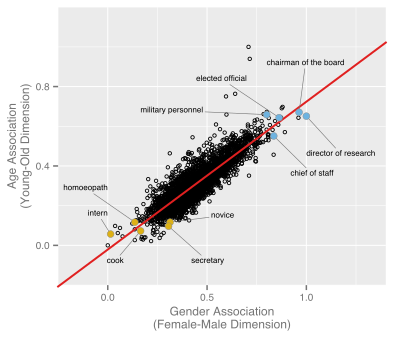

In [60]:
import statsmodels.formula.api as smf
import html

from IPython.display import HTML, SVG, display

import plotly.graph_objects as go
from matplotlib.ticker import FixedLocator, FormatStrFormatter, MultipleLocator

#CSV column names vs paper
COL_AGE = "age_norm.main"
COL_GENDER = "gender_norm.main"
assert COL_AGE in df.columns and COL_GENDER in df.columns, (
    f"Expected {COL_AGE!r} and {COL_GENDER!r}; got {list(df.columns)}"
)

reg = df.rename(
    columns={"Social.Category": "category", COL_AGE: "age_norm_main", COL_GENDER: "gender_norm_main"}
).dropna(subset=["age_norm_main", "gender_norm_main"])

ols = smf.ols("age_norm_main ~ gender_norm_main", data=reg).fit()

_OLS_SUMMARY_CSS = """
<style>
.ols-dark-summary {
  --ols-bg: var(--vscode-editor-background, var(--jp-layout-color0, #1e1e1e));
  background: var(--ols-bg);
  color: #fff;
  padding: 12px 16px;
  display: inline-block;
  font-family: system-ui, -apple-system, Segoe UI, Helvetica, Arial, sans-serif;
  font-size: 13px;
  line-height: 1.35;
}
.ols-dark-summary table.simpletable {
  border-collapse: collapse;
  background: var(--ols-bg);
  color: #fff;
  margin: 0;
}
.ols-dark-summary table.simpletable caption {
  caption-side: top;
  text-align: center;
  color: #fff;
  font-weight: bold;
  padding: 8px 4px 12px;
  background: var(--ols-bg);
}
.ols-dark-summary table.simpletable th,
.ols-dark-summary table.simpletable td {
  border: 1px solid #fff;
  color: #fff;
  background: var(--ols-bg);
  padding: 4px 10px;
  text-align: left;
  vertical-align: middle;
}
.ols-dark-summary table.simpletable th {
  font-weight: bold;
}
</style>
"""
_ols_html = ols.summary().as_html()
if "<br/><br/>Notes:" in _ols_html:
    _ols_html = _ols_html.split("<br/><br/>Notes:", 1)[0]
display(
    HTML(
        _OLS_SUMMARY_CSS
        + '<div class="ols-dark-summary">'
        + _ols_html
        + "</div>"
    )
)

assert np.isclose(ols.rsquared, 0.761, atol=1e-3), ols.rsquared
assert np.isclose(ols.params["Intercept"], -0.0211, atol=5e-4)
assert np.isclose(ols.params["gender_norm_main"], 0.7450, atol=5e-4)

#Static plot: same categories as age_gender_regression_plot.svg
REPRESENTATIVE_GOLD = [
    "cook",
    "homoeopath",
    "intern",
    "novice",
    "secretary",
]
REPRESENTATIVE_BLUE = [
    "chairman of the board",
    "chief of staff",
    "director of research",
    "elected official",
    "military personnel",
]
REPRESENTATIVE = REPRESENTATIVE_GOLD + REPRESENTATIVE_BLUE
_COL_GOLD = "#DDB115"
_COL_BLUE = "#6EB3E0"
_LINE_RED = "#E02020"

# Highlighted representative points: thin, soft outline
_HIGHLIGHT_EDGE = "#888888"
_HIGHLIGHT_EDGEWIDTH_MPL = 0.45
_HIGHLIGHT_EDGEWIDTH_PLOTLY = 0.5

# Reference palette
_REF_WHITE = "#FFFFFF"
_REF_NEUTRAL_BORDER = "#D1D1D1"
_REF_TEXT_LABEL = "#757575"
_REF_TEXT_VALUE = "#000000"
_REF_TOOLTIP_SHADOW = "0 2px 5px rgba(0,0,0,0.1)"

def _plotly_hover_row(r):
    c = html.escape(str(r["category"]))
    return (
        f'<i style="color:{_REF_TEXT_LABEL}">social_category</i> '
        f'<b style="color:{_REF_TEXT_VALUE}">{c}</b><br>'
        f'<i style="color:{_REF_TEXT_LABEL}">gender_norm</i> '
        f'<b style="color:{_REF_TEXT_VALUE}">{r["gender_norm_main"]:.2f}</b><br>'
        f'<i style="color:{_REF_TEXT_LABEL}">age_norm</i> '
        f'<b style="color:{_REF_TEXT_VALUE}">{r["age_norm_main"]:.2f}</b>'
    )


# Label anchors in data coordinates
_XLIM = (-0.25, 1.4)
_YLIM = (-0.2, 1.2)
_LABEL_STYLE = {
    "chairman of the board": {"xytext": (0.8, 0.9), "ha": "left", "va": "bottom"},
    "elected official": {"xytext": (0.7, 0.82), "ha": "right", "va": "bottom"},
    "military personnel": {"xytext": (0.48, 0.68), "ha": "right", "va": "center"},
    "director of research": {"xytext": (1.0, 0.48), "ha": "left", "va": "top"},
    "chief of staff": {"xytext": (0.92, 0.38), "ha": "left", "va": "top"},
    "homoeopath": {"xytext": (0.0, 0.27), "ha": "right", "va": "bottom"},
    "intern": {"xytext": (0.0, 0.16), "ha": "right", "va": "center"},
    "cook": {"xytext": (0.08, -0.06), "ha": "right", "va": "top"},
    "secretary": {"xytext": (0.42, -0.06), "ha": "left", "va": "top"},
    "novice": {"xytext": (0.52, 0.15), "ha": "left", "va": "center"},
}

# Static figure style aligned with reference age_gender_regression_plot.svg
_FACE = "#ebebeb"
_GRID = "#ffffff"
_TICKLABEL = _REF_TEXT_LABEL
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans", "sans-serif"]
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.set_facecolor(_FACE)
fig.patch.set_facecolor("#ffffff")
ax.set_axisbelow(True)
ax.grid(True, which="major", color=_GRID, linewidth=1.0, linestyle="-")
ax.grid(True, which="minor", color=_GRID, linewidth=0.5, linestyle="-")
ax.xaxis.set_major_locator(FixedLocator([0.0, 0.5, 1.0]))
ax.xaxis.set_minor_locator(MultipleLocator(0.25))
ax.yaxis.set_major_locator(FixedLocator([0.0, 0.4, 0.8]))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

ax.scatter(
    reg["gender_norm_main"],
    reg["age_norm_main"],
    s=12,
    facecolors="none",
    edgecolors="#000000",
    linewidths=0.89,
    zorder=2,
)

_intercept = float(ols.params.Intercept)
_slope = float(ols.params["gender_norm_main"])

# Plotly draws the full line segment
_x_lo = 0.0 if _intercept >= 0 else max(0.0, -_intercept / _slope)
_x_hi = 1.0
if _intercept + _slope * _x_hi > 1.0:
    _x_hi = float((1.0 - _intercept) / _slope)
    
# Plotly OLS
_plotly_x_ext = -0.02
_n_ext = 40
gx_ext = np.linspace(_plotly_x_ext, _x_lo, _n_ext)
y_ext = _intercept + _slope * gx_ext
gx_in = np.linspace(_x_lo, _x_hi, 100)
y_in = np.clip(_intercept + _slope * gx_in, 0.0, 1.0)
gx_line_plotly = np.concatenate([gx_ext, gx_in[1:]])
yy_line_plotly = np.concatenate([y_ext, y_in[1:]])

_gx_mpl = np.linspace(_XLIM[0], _XLIM[1], 200)
_yy_mpl = _intercept + _slope * _gx_mpl
ax.plot(_gx_mpl, _yy_mpl, color=_LINE_RED, linewidth=2.0, zorder=3, clip_on=False)

for cats, col in ((REPRESENTATIVE_GOLD, _COL_GOLD), (REPRESENTATIVE_BLUE, _COL_BLUE)):
    sub = reg[reg["category"].isin(cats)]
    ax.scatter(
        sub["gender_norm_main"],
        sub["age_norm_main"],
        s=48,
        facecolors=col,
        zorder=5,
        edgecolors=_HIGHLIGHT_EDGE,
        linewidths=_HIGHLIGHT_EDGEWIDTH_MPL,
    )

for cat in REPRESENTATIVE:
    row = reg[reg["category"] == cat]
    if row.empty:
        continue
    x = float(row["gender_norm_main"].iloc[0])
    y = float(row["age_norm_main"].iloc[0])
    st = _LABEL_STYLE[cat]
    ax.annotate(
        cat,
        xy=(x, y),
        xytext=st["xytext"],
        textcoords="data",
        fontsize=8,
        arrowprops=dict(arrowstyle="-", color=_REF_TEXT_LABEL, lw=0.6, shrinkA=0, shrinkB=2),
        ha=st["ha"],
        va=st["va"],
        clip_on=False,
    )

ax.set_xlabel(
    "Gender Association\n(Female-Male Dimension)",
    fontweight="bold",
    fontsize=12,
    color=_TICKLABEL,
)
ax.set_ylabel(
    "Age Association\n(Young-Old Dimension)",
    fontweight="bold",
    fontsize=12,
    color=_TICKLABEL,
)
ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax.tick_params(
    axis="both",
    which="major",
    colors=_TICKLABEL,
    labelsize=10,
    direction="out",
    length=5,
    width=1.5,
    bottom=True,
    top=False,
    left=True,
    right=False,
)
ax.tick_params(axis="both", which="minor", length=0)
for _side in ("bottom", "left", "top", "right"):
    ax.spines[_side].set_visible(False)
ax.set_xlim(_XLIM)
ax.set_ylim(_YLIM)
ax.margins(0)
ax.set_autoscale_on(False)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(BASE / "age_gender_regression_plot.svg", format="svg", bbox_inches="tight")
plt.close(fig)
display(SVG(BASE / "age_gender_regression_plot.svg"))

reg["_plotly_hover"] = reg.apply(_plotly_hover_row, axis=1)

#Interactive Plotly (
reg_gold = reg[reg["category"].isin(REPRESENTATIVE_GOLD)]
reg_blue = reg[reg["category"].isin(REPRESENTATIVE_BLUE)]
fig_p = go.Figure()
fig_p.add_trace(
    go.Scatter(
        x=reg["gender_norm_main"],
        y=reg["age_norm_main"],
        mode="markers",
        marker=dict(
            size=7,
            opacity=0.22,
            color="#A8A8A8",
            line=dict(width=0.9, color=_REF_TEXT_VALUE),
        ),
        hovertext=reg["_plotly_hover"],
        hovertemplate="%{hovertext}<extra></extra>",
        showlegend=False,
        cliponaxis=False,
    )
)
fig_p.add_trace(
    go.Scatter(
        x=reg_gold["gender_norm_main"],
        y=reg_gold["age_norm_main"],
        mode="markers",
        marker=dict(
            size=13,
            color=_COL_GOLD,
            line=dict(width=_HIGHLIGHT_EDGEWIDTH_PLOTLY, color=_HIGHLIGHT_EDGE),
        ),
        hovertext=reg_gold["_plotly_hover"],
        hovertemplate="%{hovertext}<extra></extra>",
        showlegend=False,
        cliponaxis=False,
    )
)
fig_p.add_trace(
    go.Scatter(
        x=reg_blue["gender_norm_main"],
        y=reg_blue["age_norm_main"],
        mode="markers",
        marker=dict(
            size=13,
            color=_COL_BLUE,
            line=dict(width=_HIGHLIGHT_EDGEWIDTH_PLOTLY, color=_HIGHLIGHT_EDGE),
        ),
        hovertext=reg_blue["_plotly_hover"],
        hovertemplate="%{hovertext}<extra></extra>",
        showlegend=False,
        cliponaxis=False,
    )
)
fig_p.add_trace(
    go.Scatter(
        x=gx_line_plotly,
        y=yy_line_plotly,
        mode="lines",
        line=dict(color=_LINE_RED, width=2.5, simplify=False),
        cliponaxis=False,
        hoverinfo="skip",
        showlegend=False,
    )
)
fig_p.update_layout(
    width=750,
    height=650,
    margin=dict(l=60, r=40, t=40, b=60),
    xaxis_title="<b>Gender Association</b><br><b>(Female-Male Dimension)</b>",
    yaxis_title="<b>Age Association</b><br><b>(Young-Old Dimension)</b>",
    xaxis_title_font=dict(size=13, color=_REF_TEXT_VALUE, family="Arial Black, Helvetica Neue, Helvetica, sans-serif"),
    yaxis_title_font=dict(size=13, color=_REF_TEXT_VALUE, family="Arial Black, Helvetica Neue, Helvetica, sans-serif"),
    xaxis=dict(
        range=[0, 1],
        autorange=False,
        constrain="domain",
        tickmode="linear",
        tick0=0,
        dtick=0.1,
        tickformat=".1f",
        tickfont=dict(size=11, color=_REF_TEXT_VALUE, family="Helvetica Neue, Helvetica, Arial, sans-serif"),
        ticks="outside",
        ticklen=5,
        tickwidth=1,
        tickcolor=_REF_TEXT_VALUE,
        showgrid=True,
        gridcolor=_REF_NEUTRAL_BORDER,
        gridwidth=1,
        zeroline=False,
        showline=True,
        linewidth=1.25,
        linecolor=_REF_TEXT_VALUE,
        mirror=False,
    ),
    yaxis=dict(
        range=[0, 1],
        autorange=False,
        constrain="domain",
        tickmode="linear",
        tick0=0,
        dtick=0.1,
        tickformat=".1f",
        tickfont=dict(size=11, color=_REF_TEXT_VALUE, family="Helvetica Neue, Helvetica, Arial, sans-serif"),
        ticks="outside",
        ticklen=5,
        tickwidth=1,
        tickcolor=_REF_TEXT_VALUE,
        showgrid=True,
        gridcolor=_REF_NEUTRAL_BORDER,
        gridwidth=1,
        zeroline=False,
        showline=True,
        linewidth=1.25,
        linecolor=_REF_TEXT_VALUE,
        mirror=False,
    ),
    shapes=[
        dict(
            type="line",
            xref="x",
            yref="y",
            x0=0,
            x1=1,
            y0=1,
            y1=1,
            layer="below",
            line=dict(color=_REF_NEUTRAL_BORDER, width=1),
        ),
        dict(
            type="line",
            xref="x",
            yref="y",
            x0=1,
            x1=1,
            y0=0,
            y1=1,
            layer="below",
            line=dict(color=_REF_NEUTRAL_BORDER, width=1),
        ),
    ],
    showlegend=False,
    template="plotly_white",
    paper_bgcolor=_REF_WHITE,
    plot_bgcolor=_REF_WHITE,
    hoverlabel=dict(
        bgcolor=_REF_WHITE,
        bordercolor=_REF_NEUTRAL_BORDER,
        font=dict(
            size=12,
            family="Helvetica Neue, Helvetica, Arial, sans-serif",
            color=_REF_TEXT_VALUE,
        ),
    ),
)
_HTML_OUT = BASE / "age_gender_regression_interactive.html"
fig_p.write_html(_HTML_OUT, include_plotlyjs="cdn")
_p = _HTML_OUT.read_text(encoding="utf-8")
_css = "<style>\n" + f".hoverlayer .hovertext {{ box-shadow: {_REF_TOOLTIP_SHADOW}; border-radius: 5px; }}\n" + "</style>\n"
if "</head>" in _p and _css.strip() not in _p:
    _HTML_OUT.write_text(_p.replace("</head>", _css + "</head>", 1), encoding="utf-8")

**Outliers and what the figure highlights**

The static plot spotlights a small set of **illustrative** occupations (e.g. “chairman of the board”, “intern”, “cook”) that sit at informative positions along the gender-age gradient or illustrate familiar social roles. Many **other** points lie far from the regression line-categories with strong residual age for their gender score, or extreme on one axis. Those are equally “outliers” in a statistical sense, but naming every one would clutter the figure and dilute the narrative, authors typically **curate** labels for clarity. The interactive plot matters because **hover** reveals those unlabeled extremes (and mid-list categories), so readers can judge how much of the cloud is driven by a few distant points versus a smooth association—highlighting choices shape which deviations readers notice.

## Part 3 - Amplification via Google Search

In the **image-search experiment** participants were randomized to **treatment** (upload an image of an occupation from Google Images) or **control** (upload a neutral image, then rate age for a random occupation). We compare **estimated age** of occupation in the treatment group to **baseline** estimates from the control group.

**Data:** `experiment_control.csv` and `experiment_treatment.csv`

**Distortion score (per row):** for each treatment response, subtract the **mean** `age` for that **same occupation** (`category`) in the control group. Call this `age_cent` (“estimated age relative to control”). Drop rows where the uploaded image gender is `Not Sure`.

**Figure:** overlaid **density** plots of `age_cent` for **Female** vs **Male** image uploads vertical line at **0**, optional vertical lines at **group means** - saved as `estimated_age_gender_image_search_distortion.svg`.

**Tests:**

1. **Female vs Male** on `age_cent` (two-sample `t.test`).
2. **Female** `age_cent` vs 0 (one-sample).
3. **Male** `age_cent` vs 0 (one-sample).
4. **Occupation + participant fixed effects:** combined OLS of **`age`** on **`(condition × gender)`** + **`category`** + **`subj`** (Treatment coding; **Female vs Male within Image** = `Female` + `Image×Female`). Print the **full OLS summary**; then a **baseline** model `age ~ category + subj`, **predictions** and **residuals** on the stacked data, saved as **`grouped_plot.svg`** and **`grouped_plot_residuals.svg`**; finally **two Type III ANOVAs** with **Sum** coding on `condition` and `gender` (with and without `category` + `subj`).

Reference effect sizes from the paper (for comparison): female vs male uploaders ≈ **5.46 years** younger for women’s images, female vs control ≈ **−1.75** years, male vs control ≈ **+0.64** years.

**Which test matches the Nature headline?** The paper’s **~5.46 years** and **t ≈ −19** refer to **female vs male image uploaders** with **occupation held constant**—the same contrast as **Female** + **Image×Female** in the fixed-effects OLS under *Investigate the Amplification* (Treatment coding; Male and Control as references). A **marginal** two-sample *t*-test on `age_cent` pools rows without that structure, so it is a **different estimand** and need not match the headline *t*.

The **one-sample** tests (Female vs 0, Male vs 0 on `age_cent`) align with the **−1.75** and **+0.64** year effects **relative to control** in the paper’s paragraph.

age_cent: mean(Female) = -1.749, mean(Male) = 0.641, mean(F) - mean(M) = -2.390
Two-sample: t = -9.841, p = 1.270e-22, df ≈ 4512.5
Female vs 0: t = -11.323, p = 4.818e-29
Male vs 0: t = 3.420, p = 6.374e-04

Note: The pooled Welch t-test (Female vs Male on age_cent) is not the same estimand as the Nature ~5.46y headline (occupation-constant FE contrast; see markdown above). The next section fits OLS with occupation + participant fixed effects and reports female vs male within the Image condition.


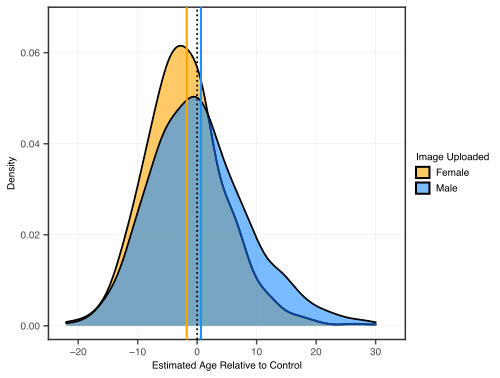

In [61]:
from pathlib import Path

from IPython.display import SVG, display
from scipy.stats import levene, ttest_1samp, ttest_ind

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from matplotlib.colors import to_rgba
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator


BASE = Path.cwd()

_CONTROL_PATH = BASE / "experiment_control.csv"
_TREATMENT_PATH = BASE / "experiment_treatment.csv"
if not _CONTROL_PATH.is_file() or not _TREATMENT_PATH.is_file():
    raise FileNotFoundError(
        f"Expected {_CONTROL_PATH.name} and {_TREATMENT_PATH.name} in {BASE.resolve()}. "
        "Download the replication CSVs from the authors’ Google Drive (see README.md)."
    )

control_exp = pd.read_csv(_CONTROL_PATH)
treatment_exp = pd.read_csv(_TREATMENT_PATH)

control_agg = (
    control_exp.groupby("category", as_index=False)
    .agg(c_age=("age", "mean"), c_ideal=("ideal_age", "mean"))
)
treatment_full = treatment_exp.merge(control_agg, on="category", how="inner")
treatment_full["age_cent"] = treatment_full["age"] - treatment_full["c_age"]
treatment_main = treatment_full[treatment_full["gender"] != "Not Sure"].copy()

female = treatment_main.loc[treatment_main["gender"] == "Female", "age_cent"].astype(float).dropna()
male = treatment_main.loc[treatment_main["gender"] == "Male", "age_cent"].astype(float).dropna()

# R default for two-sample t.test is Welch - unequal variances
tt_fm = ttest_ind(female, male, equal_var=False, nan_policy="omit")
tt_f0 = ttest_1samp(female, popmean=0.0, nan_policy="omit")
tt_m0 = ttest_1samp(male, popmean=0.0, nan_policy="omit")

mean_f, mean_m = float(female.mean()), float(male.mean())

print(
    "age_cent: mean(Female) = {:.3f}, mean(Male) = {:.3f}, mean(F) - mean(M) = {:.3f}".format(
        mean_f, mean_m, mean_f - mean_m
    )
)
print(
    "Two-sample: t = {:.3f}, p = {:.3e}, df ≈ {:.1f}".format(
        tt_fm.statistic,
        tt_fm.pvalue,
        float(getattr(tt_fm, "df", float("nan"))),
    )
)
print(
    "Female vs 0: t = {:.3f}, p = {:.3e}".format(tt_f0.statistic, tt_f0.pvalue)
)
print(
    "Male vs 0: t = {:.3f}, p = {:.3e}".format(tt_m0.statistic, tt_m0.pvalue)
)
print(
    "\nNote: The pooled Welch t-test (Female vs Male on age_cent) is not the same estimand as "
    "the Nature ~5.46y headline (occupation-constant FE contrast; see markdown above). The "
    "next section fits OLS with occupation + participant fixed effects and reports female vs "
    "male within the Image condition."
)

# Density plot - estimated_age_gender_image_search_distortion.svg
_FEMALE = "#ffa500"
_MALE = "#1e90ff"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans", "sans-serif"]

sub_f = treatment_main[treatment_main["gender"] == "Female"]
sub_m = treatment_main[treatment_main["gender"] == "Male"]

fig, ax = plt.subplots(figsize=(6.4, 6.0), dpi=100)
ax.set_facecolor("#ffffff")

_kws = dict(x="age_cent", common_norm=False, cut=0, ax=ax)
# Filled areas (Male above Female)
sns.kdeplot(
    data=sub_f,
    clip=(-22, 30),
    fill=True,
    color=_FEMALE,
    alpha=0.6,
    linewidth=0,
    zorder=1,
    **_kws,
)
sns.kdeplot(
    data=sub_m,
    clip=(-22, 30),
    fill=True,
    color=_MALE,
    alpha=0.6,
    linewidth=0,
    zorder=2,
    **_kws,
)

# Outlines
_MALE_EDGE = "#0d47a1"
sns.kdeplot(data=sub_m, clip=(-22, 30), fill=False, color="#000000", linewidth=1.77, zorder=5, **_kws)
sns.kdeplot(
    data=sub_f, clip=(-22, 30), fill=False, 
    color="#000000", linewidth=1.77, zorder=4, **_kws)

x_split = 1.9 
sns.kdeplot(
    data=sub_f, clip=(x_split, 30),
    fill=False, color=_MALE_EDGE, linewidth=1.77, zorder=4, **_kws,
)
ax.set_xlim(-25, 35)
ax.axvline(0.0, color="#000000", linestyle=":", linewidth=1.77, zorder=5)
ax.axvline(mean_f, color=_FEMALE, linewidth=2.13, zorder=6)
ax.axvline(mean_m, color=_MALE, linewidth=2.13, zorder=6)
_ylim_top = ax.get_ylim()[1]
ax.set_ylim(bottom=-0.003, top=max(_ylim_top * 1.03, 0.07))
ax.set_xlabel("Estimated Age Relative to Control")
ax.set_ylabel("Density")

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("#333333")
ax.tick_params(
    axis="x",
    which="major",
    direction="out",
    length=5,
    width=1.5,
    colors="#4d4d4d",
    bottom=True,
    top=False,
)
ax.tick_params(
    axis="y",
    which="major",
    direction="out",
    length=5,
    width=1.5,
    colors="#4d4d4d",
    left=True,
    right=False,
    labelleft=True,
    labelright=False,
)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.02))

# Light grid on both axes
ax.grid(
    True,
    axis="both",
    linestyle="-",
    linewidth=0.5,
    color="#e5e5e5",
    zorder=0,
)
ax.set_axisbelow(True)

_leg = ax.legend(
    handles=[
        Patch(facecolor=to_rgba(_FEMALE, 0.6), edgecolor="#000000", linewidth=2.0, label="Female"),
        Patch(facecolor=to_rgba(_MALE, 0.6), edgecolor="#000000", linewidth=2.0, label="Male"),
    ],
    title="Image Uploaded",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    handlelength=1.35,
    handleheight=1.35,
    handletextpad=0.65,
    borderpad=0.35,
    labelspacing=0.45,
    alignment="left",
)
_leg.get_title().set_ha("left")

_OUT_SVG = BASE / "estimated_age_gender_image_search_distortion.svg"
fig.savefig(_OUT_SVG, format="svg", bbox_inches="tight", facecolor="white")
plt.close(fig)
display(SVG(_OUT_SVG))

### Part 4 - Investigate the Amplification

Following the **Investigate the Amplification** section of the assignment: stack **control** and **treatment**, then regress **`age`** on **`(condition × gender)`** with **Treatment** coding (**Control**, **Male** as references), plus **`category`** and **`subj`** fixed effects. The **female vs male** difference **within the Image (treatment) arm**, net of those fixed effects, is the linear combination **`Female` main effect + `Image × Female` interaction**. That is the “holding occupation constant” contrast behind the Nature summary (~**5.46** years in the paper; your replication CSV may differ slightly in point estimate).


In [62]:
import statsmodels.formula.api as smf
from scipy import stats
from IPython.display import HTML, display

_cols = ["subj", "category", "age", "gender", "condition"]
combined_exp = pd.concat(
    [control_exp[_cols], treatment_exp[_cols]],
    ignore_index=True,
)
combined_main = combined_exp[combined_exp["gender"] != "Not Sure"].copy()

_fe_formula = (
    "age ~ C(condition, Treatment(reference='Control')) * "
    "C(gender, Treatment(reference='Male')) + C(category) + C(subj)"
)
fe_ols = smf.ols(_fe_formula, data=combined_main).fit()

_OLS_SUMMARY_CSS = """
<style>
.ols-dark-summary {
  --ols-bg: #111;
  background: var(--ols-bg);
  color: #fff;
  padding: 12px 16px;
  display: inline-block;
  font-family: system-ui, -apple-system, Segoe UI, Helvetica, Arial, sans-serif;
  font-size: 13px;
  line-height: 1.35;
}
.ols-dark-summary table.simpletable {
  border-collapse: collapse;
  background: var(--ols-bg);
  color: #fff;
  margin: 0;
}
.ols-dark-summary table.simpletable caption {
  caption-side: top;
  text-align: center;
  color: #fff;
  font-weight: bold;
  padding: 8px 4px 12px;
  background: var(--ols-bg);
}
.ols-dark-summary table.simpletable th,
.ols-dark-summary table.simpletable td {
  border: 1px solid #555;
  color: #fff;
  background: var(--ols-bg);
  padding: 4px 10px;
  text-align: left;
  vertical-align: middle;
}
.ols-dark-summary table.simpletable thead th {
  text-align: center;
  font-weight: bold;
}
.ols-dark-summary table.simpletable th {
  font-weight: bold;
}
</style>
"""
_fe_html = fe_ols.summary().as_html()
display(HTML(_OLS_SUMMARY_CSS + '<div class="ols-dark-summary">' + _fe_html + "</div>"))

_fem = "C(gender, Treatment(reference='Male'))[T.Female]"
_int = (
    "C(condition, Treatment(reference='Control'))[T.Image]:"
    "C(gender, Treatment(reference='Male'))[T.Female]"
)
beta_fm_image = float(fe_ols.params[_fem] + fe_ols.params[_int])
cov = fe_ols.cov_params()
se_fm_image = float(
    np.sqrt(
        cov.loc[_fem, _fem]
        + cov.loc[_int, _int]
        + 2 * cov.loc[_fem, _int]
    )
)
t_fm_image = beta_fm_image / se_fm_image
p_fm_image = 2 * stats.t.sf(abs(t_fm_image), fe_ols.df_resid)

print("OLS: age ~ (condition × gender) + C(category) + C(subj)")
print(
    "  R² = {:.3f}, Adj. R² = {:.3f}, n = {:.0f}".format(
        fe_ols.rsquared, fe_ols.rsquared_adj, fe_ols.nobs
    )
)
print(
    "Female vs Male | Image: "
    "β = {:.3f} years, SE = {:.3f}, t = {:.3f}, two-sided p = {:.3e}".format(
        beta_fm_image, se_fm_image, t_fm_image, p_fm_image
    )
)
print(
    "Paper headline: ~5.46 years (t ≈ −19), this replication file: β ≈ {:.2f} (t ≈ {:.2f}).".format(
        beta_fm_image, t_fm_image
    )
)


OLS: age ~ (condition × gender) + C(category) + C(subj)
  R² = 0.586, Adj. R² = 0.560, n = 8514
Female vs Male | Image: β = -3.041 years, SE = 0.235, t = -12.946, two-sided p = 5.916e-38
Paper headline: ~5.46 years (t ≈ −19), this replication file: β ≈ -3.04 (t ≈ -12.95).


### Baseline model (occupation + participant only) and grouped plots

A second model uses only **`C(category) + C(subj)`**-the same fixed effects as in the full model, but **without** condition or gender. In-sample **predicted** ages from this baseline isolate “typical” age for that occupation and participant. The first figure groups those predictions by **condition × gender**, the second groups **residuals** (observed age minus baseline prediction), highlighting what condition and gender explain on top of occupation and participant means.

In [63]:
from pathlib import Path

from IPython.display import Markdown, display

BASE = Path.cwd()

_baseline_formula = "age ~ C(category) + C(subj)"
baseline_ols = smf.ols(_baseline_formula, data=combined_main).fit()

_gp = combined_main.copy()
_gp["pred_baseline"] = baseline_ols.predict(_gp)
_gp["resid_baseline"] = _gp["age"] - _gp["pred_baseline"]

print("Baseline OLS: age ~ C(category) + C(subj)")
print(
    "R² = {:.3f}, Adj. R² = {:.3f}, n = {:.0f}".format(
        baseline_ols.rsquared,
        baseline_ols.rsquared_adj,
        baseline_ols.nobs,
    )
)

from scipy import stats

from matplotlib.ticker import FormatStrFormatter

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"]

_FEMALE = "#ffa500"
_MALE = "#1e90ff"
_FIGSIZE = (551 / 72, 408 / 72)


def _mean_se(series):
    x = np.asarray(series.dropna(), dtype=float)
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan
    m = float(np.mean(x))
    if n < 2:
        return m, m, m
    se = float(stats.sem(x))
    return m, m - se, m + se


def _style_axes(ax):
    ax.set_facecolor("#ffffff")
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_color("#262626")
    ax.tick_params(axis="both", colors="#262626")


def _plot_condition_gender_lines(
    ax, ycol, ylabel, *, yline0=False, ylim=None, legend_loc="center right"
):
    conds = ["Control", "Image"]
    # Centered tick positions (not 0/1) so labels sit closer together mid-axis
    xi = np.linspace(0.25, 0.75, len(conds))
    if yline0:
        ax.axhline(0.0, color="#262626", linestyle=":", linewidth=1.2, zorder=0)
    for gender, color, label in (
        ("Female", _FEMALE, "Female"),
        ("Male", _MALE, "Male"),
    ):
        means, los, his = [], [], []
        for c in conds:
            sub = _gp.loc[(_gp["condition"] == c) & (_gp["gender"] == gender), ycol]
            m, lo, hi = _mean_se(sub)
            means.append(m)
            los.append(lo)
            his.append(hi)
        means = np.asarray(means, dtype=float)
        los = np.asarray(los, dtype=float)
        his = np.asarray(his, dtype=float)
        ax.errorbar(
            xi,
            means,
            yerr=[means - los, his - means],
            fmt="none",
            ecolor=color,
            elinewidth=1.5,
            capsize=0,
            zorder=2,
        )
        ax.plot(
            xi,
            means,
            "o-",
            color=color,
            lw=1.5,
            ms=6,
            markerfacecolor=color,
            markeredgecolor=color,
            markeredgewidth=1,
            label=label,
            zorder=3,
        )
    ax.set_xticks(xi)
    ax.set_xticklabels(conds)
    ax.set_xlim(0, 1)
    ax.set_xlabel("condition")
    ylabel_kwargs = {}
    if ylim is not None:
        lo, hi = float(ylim[0]), float(ylim[1])
        span = hi - lo
        pad = 0.08 * span
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_yticks(np.linspace(lo, hi, 5))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ylabel_kwargs = {"fontsize": 14}
    ax.set_ylabel(ylabel, **ylabel_kwargs)
    _style_axes(ax)
    if ylim is not None:
        ax.tick_params(axis="y", labelsize=14)
    leg = ax.legend(
        frameon=True,
        framealpha=0.8,
        edgecolor="#cccccc",
        facecolor="#ffffff",
        loc=legend_loc,
    )


fig, ax = plt.subplots(figsize=_FIGSIZE, dpi=100)
_plot_condition_gender_lines(ax, "pred_baseline", "predicted")
fig.tight_layout()
_out_gp = BASE / "grouped_plot.svg"
fig.savefig(_out_gp, format="svg", bbox_inches="tight", facecolor="white")
plt.close(fig)

fig, ax = plt.subplots(figsize=_FIGSIZE, dpi=100)
_plot_condition_gender_lines(
    ax,
    "resid_baseline",
    "residuals",
    yline0=False,
    ylim=(-1, 1),
    legend_loc="center right",
)
fig.tight_layout()
_out_gr = BASE / "grouped_plot_residuals.svg"
fig.savefig(_out_gr, format="svg", bbox_inches="tight", facecolor="white")
plt.close(fig)
_gp_md = (
    '<div style="display:grid;grid-template-columns:1fr 1fr;gap:20px;width:100%;'
    'align-items:start;box-sizing:border-box">'
    f'<div style="min-width:0"><img src="{_out_gp.name}" style="width:100%;height:auto;'
    'display:block" alt="Baseline predictions by condition and gender"/></div>'
    f'<div style="min-width:0"><img src="{_out_gr.name}" style="width:100%;height:auto;'
    'display:block" alt="Baseline residuals by condition and gender"/></div></div>'
)
display(Markdown(_gp_md))

Baseline OLS: age ~ C(category) + C(subj)
R² = 0.576, Adj. R² = 0.550, n = 8514


<div style="display:grid;grid-template-columns:1fr 1fr;gap:20px;width:100%;align-items:start;box-sizing:border-box"><div style="min-width:0"><img src="grouped_plot.svg" style="width:100%;height:auto;display:block" alt="Baseline predictions by condition and gender"/></div><div style="min-width:0"><img src="grouped_plot_residuals.svg" style="width:100%;height:auto;display:block" alt="Baseline residuals by condition and gender"/></div></div>

**Observations**

- **Baseline** (`age ~ C(category) + C(subj)`): Only occupation and participant fixed effects—no condition or image gender. **R² = 0.576**, **Adj. R² = 0.550**, **n = 8,514**. Most explainable variance sits here; the full model with **(condition × gender)** plus the same FEs raises R² only modestly (~0.01), so the experiment adds a thin layer on top of rater–occupation structure.
- **`grouped_plot.svg`**: Mean **baseline predictions** by **Control vs Image** and **Female vs Male** labels (±1 SE). Predictions do not condition on condition/gender; any spread across cells partly reflects **who/which occupation** lands in each cell, not a term for treatment in this model.
- **`grouped_plot_residuals.svg`**: **Observed age − baseline prediction** (y-axis −1…1), same layout. After removing occupation–participant means, **residuals** still vary by condition and label—evidence of effects **beyond** baseline norms, consistent with the amplification story and the full OLS / within–Image female–male contrast.


### ANOVA with Sum coding

Two **Type III** ANOVA tables (Sum contrasts for `condition` and `gender` as in the assignment). The **first** model uses only **`condition * gender`**. The **second** adds **`category`** and **`subj`**, matching the structure of the OLS with fixed effects—so you can compare whether the interaction is substantial before and after absorbing occupation and participant. The **condition × gender** row in the second table is the same interaction tested in the Treatment-coded FE regression (same data; different parameterization).

In [64]:
from statsmodels.stats.anova import anova_lm
from IPython.display import HTML, display

_OLS_SUMMARY_CSS = """
<style>
.ols-dark-summary {
  --ols-bg: #111;
  background: var(--ols-bg);
  color: #fff;
  padding: 12px 16px;
  display: inline-block;
  font-family: system-ui, -apple-system, Segoe UI, Helvetica, Arial, sans-serif;
  font-size: 13px;
  line-height: 1.35;
}
.ols-dark-summary table.simpletable {
  border-collapse: collapse;
  background: var(--ols-bg);
  color: #fff;
  margin: 0;
}
.ols-dark-summary table.simpletable caption {
  caption-side: top;
  text-align: center;
  color: #fff;
  font-weight: bold;
  padding: 8px 4px 12px;
  background: var(--ols-bg);
}
.ols-dark-summary table.simpletable th,
.ols-dark-summary table.simpletable td {
  border: 1px solid #555;
  color: #fff;
  background: var(--ols-bg);
  padding: 4px 10px;
  text-align: left;
  vertical-align: middle;
}
.ols-dark-summary table.simpletable thead th {
  text-align: center;
  font-weight: bold;
}
.ols-dark-summary table.simpletable th {
  font-weight: bold;
}
</style>
"""

_anova1_formula = "age ~ C(condition, Sum) * C(gender, Sum)"
anova1 = smf.ols(_anova1_formula, data=combined_main).fit()
_anova1_tbl = anova_lm(anova1, typ=3).to_html(classes="simpletable", border=0)
display(
    HTML(
        _OLS_SUMMARY_CSS
        + '<div class="ols-dark-summary"><p style="color:#fff;font-weight:bold;margin:0 0 10px 0;">'
        "ANOVA (Type III): age ~ C(condition, Sum) * C(gender, Sum)"
        + "</p>"
        + _anova1_tbl
        + "</div>"
    )
)

_anova2_formula = (
    "age ~ C(condition, Sum) * C(gender, Sum) + C(category) + C(subj)"
)
anova2 = smf.ols(_anova2_formula, data=combined_main).fit()
_anova2_tbl = anova_lm(anova2, typ=3).to_html(classes="simpletable", border=0)
display(
    HTML(
        _OLS_SUMMARY_CSS
        + '<div class="ols-dark-summary"><p style="color:#fff;font-weight:bold;margin:0 0 10px 0;">ANOVA (Type III): age ~ C(condition, Sum) * C(gender, Sum) + C(category) + C(subj)</p>'
        + _anova2_tbl
        + "</div>"
    )
)

,sum_sq,df,F,PR(>F)
Intercept,1.139983e+07,1.0,120336.810293,0.000000e+00
"C(condition, Sum)",6.586653e+01,1.0,0.695288,4.043949e-01
"C(gender, Sum)",7.192011e+04,1.0,759.189711,3.692167e-160
"C(condition, Sum):C(gender, Sum)",3.473679e+02,1.0,3.666820,5.553946e-02
Residual,8.061755e+05,8510.0,NaN,NaN


,sum_sq,df,F,PR(>F)
Intercept,95563.761652,1.0,2102.726456,0.000000e+00
"C(condition, Sum)",615.340155,1.0,13.539568,2.351199e-04
"C(gender, Sum)",7053.500388,1.0,155.200901,2.685266e-35
C(category),230669.638586,53.0,95.764404,0.000000e+00
C(subj),456023.489314,453.0,22.150246,0.000000e+00
"C(condition, Sum):C(gender, Sum)",329.073698,1.0,7.240736,7.141576e-03
Residual,363807.622227,8005.0,NaN,NaN


**Observations**

- **ANOVAs**: Without FEs, **gender** and **condition × gender** dominate (raw `age` mixes occupations and participants). After adding **`category`** and **`subj`**, the **condition × gender** *F*-test asks whether image×label effects remain **on top of** those fixed effects—the same question as the interaction block in the FE OLS and the **Female** + **Image×Female** contrast for the Nature headline.